# Investigate ChromBPNet output

create bed files with marker peaks of each cell type to asses </br>
Investigate contribution scores

##### suppressPackageStartupMessages(library(ArchR))
suppressPackageStartupMessages(library(parallel))
library(ggseqlogo)

In [3]:
here::i_am("atac/chrombpnet/contribution_markers.ipynb")

source(here::here("settings.R"))
source(here::here("utils.R"))


here() starts at /rds/project/rds-SDzz0CATGms/users/bt392/atlasses/gastrulation_multiome/code



In [11]:
outdir = '/rds/project/rds-SDzz0CATGms/users/bt392/atlasses/gastrulation_multiome/results/atac/chrombpnet/'

In [4]:
ArchRProject = loadArchRProject(io$archR.directory)

Successfully loaded ArchRProject!


                                                   / |
                                                 /    \
            .                                  /      |.
            \\\                              /        |.
              \\\                          /           `|.
                \\\                      /              |.
                  \                    /                |\
                  \\#####\           /                  ||
                ==###########>      /                   ||
                 \\##==......\    /                     ||
            ______ =       =|__ /__                     ||      \\\
        ,--' ,----`-,__ ___/'  --,-`-===================##========>
       \               '        ##_______ _____ ,--,__,=##,__   ///
        ,    __==    ___,-,__,--'#'  ==='      `-'    | ##,-/
        -,____,---'       \\####\\________________,--\\_##,/
           ___      .______        ______  __    __  .____

In [13]:
library(data.table)
library(dplyr)
library(purrr)
library(stringr)

In [6]:
celltypes = c(
'Gut','Mesenchyme','Primitive_Streak','Nascent_mesoderm',
'Forebrain_Midbrain_Hindbrain','Somitic_mesoderm','Spinal_cord',
'Endothelium','Allantois','Cardiomyocytes','Erythroid1'
)

In [7]:
markers = fread('/rds/project/rds-SDzz0CATGms/users/bt392/atlasses/gastrulation_multiome/results/atac/archR/differential/pseudobulk/celltype/PeakMatrix/parsed/markers_filt.txt.gz')[celltype %in% celltypes]

In [8]:
markers_top = markers %>%
    .[order(celltype, -logFC)] %>% 
    .[, head(.SD, 50), by = 'celltype']

In [9]:
peaks = markers_top %>%
    .[,`:=`(
            start = str_split(feature, ':') %>% 
                map_chr(2) %>% 
                str_split(., '-') %>%
                map_chr(1) %>% 
                as.numeric(.),
            end = str_split(feature, ':') %>% 
                map_chr(2) %>% 
                str_split(., '-') %>%
                map_chr(2) %>% 
                as.numeric(.)
            )
      ] %>%
    .[, middle := start + (end - start) / 2] %>%
    .[,`:=`(
            seqnames = str_split(feature, ':') %>% 
                map_chr(1),
            start = middle - 1057, 
            end = middle + 1057,
            column4 = celltype,
            column5 = score,
            column6 = logFC,
            column7 = '.',
            column8 = '.',
            column9 = '.',
            column10 = 1057)] %>% 
    .[,.(seqnames, 
         start, 
         end, 
         column4,
         column5,
         column6,
         column7,
         column8,
         column9,
         column10)]

nrow(peaks)
head(peaks)

[1] 550

seqnames,start,end,column4,column5,column6,column7,column8,column9,column10
<chr>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<dbl>
chr2,161737651,161739765,Allantois,1.00,6.29,.,.,.,1057
chr4,106071241,106073355,Allantois,1.00,6.28,.,.,.,1057
chr4,12269910,12272024,Allantois,1.00,6.21,.,.,.,1057
chr11,85946231,85948345,Allantois,1.00,5.95,.,.,.,1057
chr15,61791713,61793827,Allantois,1.00,5.94,.,.,.,1057
chr4,86954618,86956732,Allantois,0.97,5.87,.,.,.,1057


In [10]:
peaks.gr = GenomicRanges::makeGRangesFromDataFrame(peaks, keep.extra.columns = T)
overlaps = GenomicRanges::findOverlaps(peaks.gr, ArchRProject@genomeAnnotation$blacklist)

peaks.gr = peaks.gr[-queryHits(overlaps)]

In [12]:
peaks = as.data.table(peaks.gr)[,`:=`(width=NULL, strand=NULL)]
fwrite(peaks, sprintf('%s/marker_peaks.bed', outdir), col.names = F, sep = '\t')

In [15]:
writeLines(paste0(
    sapply(celltypes, function(celltype){
        print(sprintf('sbatch marker_predictions_args.sh %s', 
                       celltype))
    })),
   "get_contributions.txt")

[1] "sbatch marker_predictions_args.sh Gut"
[1] "sbatch marker_predictions_args.sh Mesenchyme"
[1] "sbatch marker_predictions_args.sh Primitive_Streak"
[1] "sbatch marker_predictions_args.sh Nascent_mesoderm"
[1] "sbatch marker_predictions_args.sh Forebrain_Midbrain_Hindbrain"
[1] "sbatch marker_predictions_args.sh Somitic_mesoderm"
[1] "sbatch marker_predictions_args.sh Spinal_cord"
[1] "sbatch marker_predictions_args.sh Endothelium"
[1] "sbatch marker_predictions_args.sh Allantois"
[1] "sbatch marker_predictions_args.sh Cardiomyocytes"
[1] "sbatch marker_predictions_args.sh Erythroid1"


In [19]:
getwd()

[1] "/rds/project/rds-SDzz0CATGms/users/bt392/atlasses/gastrulation_multiome/code/atac/chrombpnet"

In [76]:
peaks = fread('/rds/project/rds-SDzz0CATGms/users/bt392/atlasses/gastrulation_multiome/results/atac/chrombpnet/predictions/Allantois_prediction.interpreted_regions.bed') %>% 
    .[, I := .I]

In [206]:
profiles = mclapply(celltypes, function(celltype){
    tmp = h5read(
        sprintf('/rds/project/rds-SDzz0CATGms/users/bt392/atlasses/gastrulation_multiome/results/atac/chrombpnet/predictions/%s_prediction.profile_scores.h5', celltype), 
        "/projected_shap/seq")
    return(tmp)
},mc.cores = 8)

names(profiles) = celltypes

In [207]:
row = peaks %>% .[V4 == 'Endothelium'] %>% .$I %>% .[1]
width = 350
plot_peak = function(row, width = 350, celltypes_plot = celltypes, centre_on_max = FALSE){
    profiles_peak = lapply(profiles, function(x){
        tmp = x[(2114 * (row-1)*4 + 1): (2114 * ((row-1) * 4) + 2114*4)]
        genome_endo = data.table(A = tmp[1:2114],
                   C = tmp[2115:4228],
                   G =  tmp[4229:6342],
                   T =  tmp[6343:8456]
                   ) %>% 
                    .[, position := .I] 

        if(centre_on_max){ # Centering does not work yet
            centre = which(profiles_peak[[celltypes_plot]] == max(profiles_peak[[celltypes_plot]]))/4+1
            genome_endo = genome_endo %>% 
                    .[position > centre - width/2 & position < centre + width/2] %>% 
                    .[, position := NULL]
        }else{
            genome_endo = genome_endo %>% 
                .[position > 1057 - width/2 & position < 1057 + width/2] %>% 
                .[, position := NULL]
        }
        
        genome_endo = as.matrix(t(genome_endo))
    })

    profiles_peak_tmp = profiles_peak[celltypes_plot]
    plots = lapply(1:length(profiles_peak_tmp), function(x){
          p1 = ggseqlogo(profiles_peak_tmp[[x]], method='custom', seq_type='dna') + ylab('my custom height') + 
            geom_hline(yintercept = 0) +
            ylim(min(sapply(profiles_peak_tmp, min)), max(sapply(profiles_peak_tmp, max))) + 
            ggtitle(names(profiles_peak_tmp)[[x]]) + 
                theme_bw() + 
                theme(panel.grid = element_blank(), 
                      panel.background = element_rect(color = 'black', fill = NA, linewidth = 1),
                      axis.text.y = element_text(size = 15),
                     axis.title.y = element_blank(),
                     axis.text.x = element_blank(),
                     axis.ticks.x = element_blank())
    })

    ggarrange(plotlist = plots, ncol = 1, align = 'hv')
}

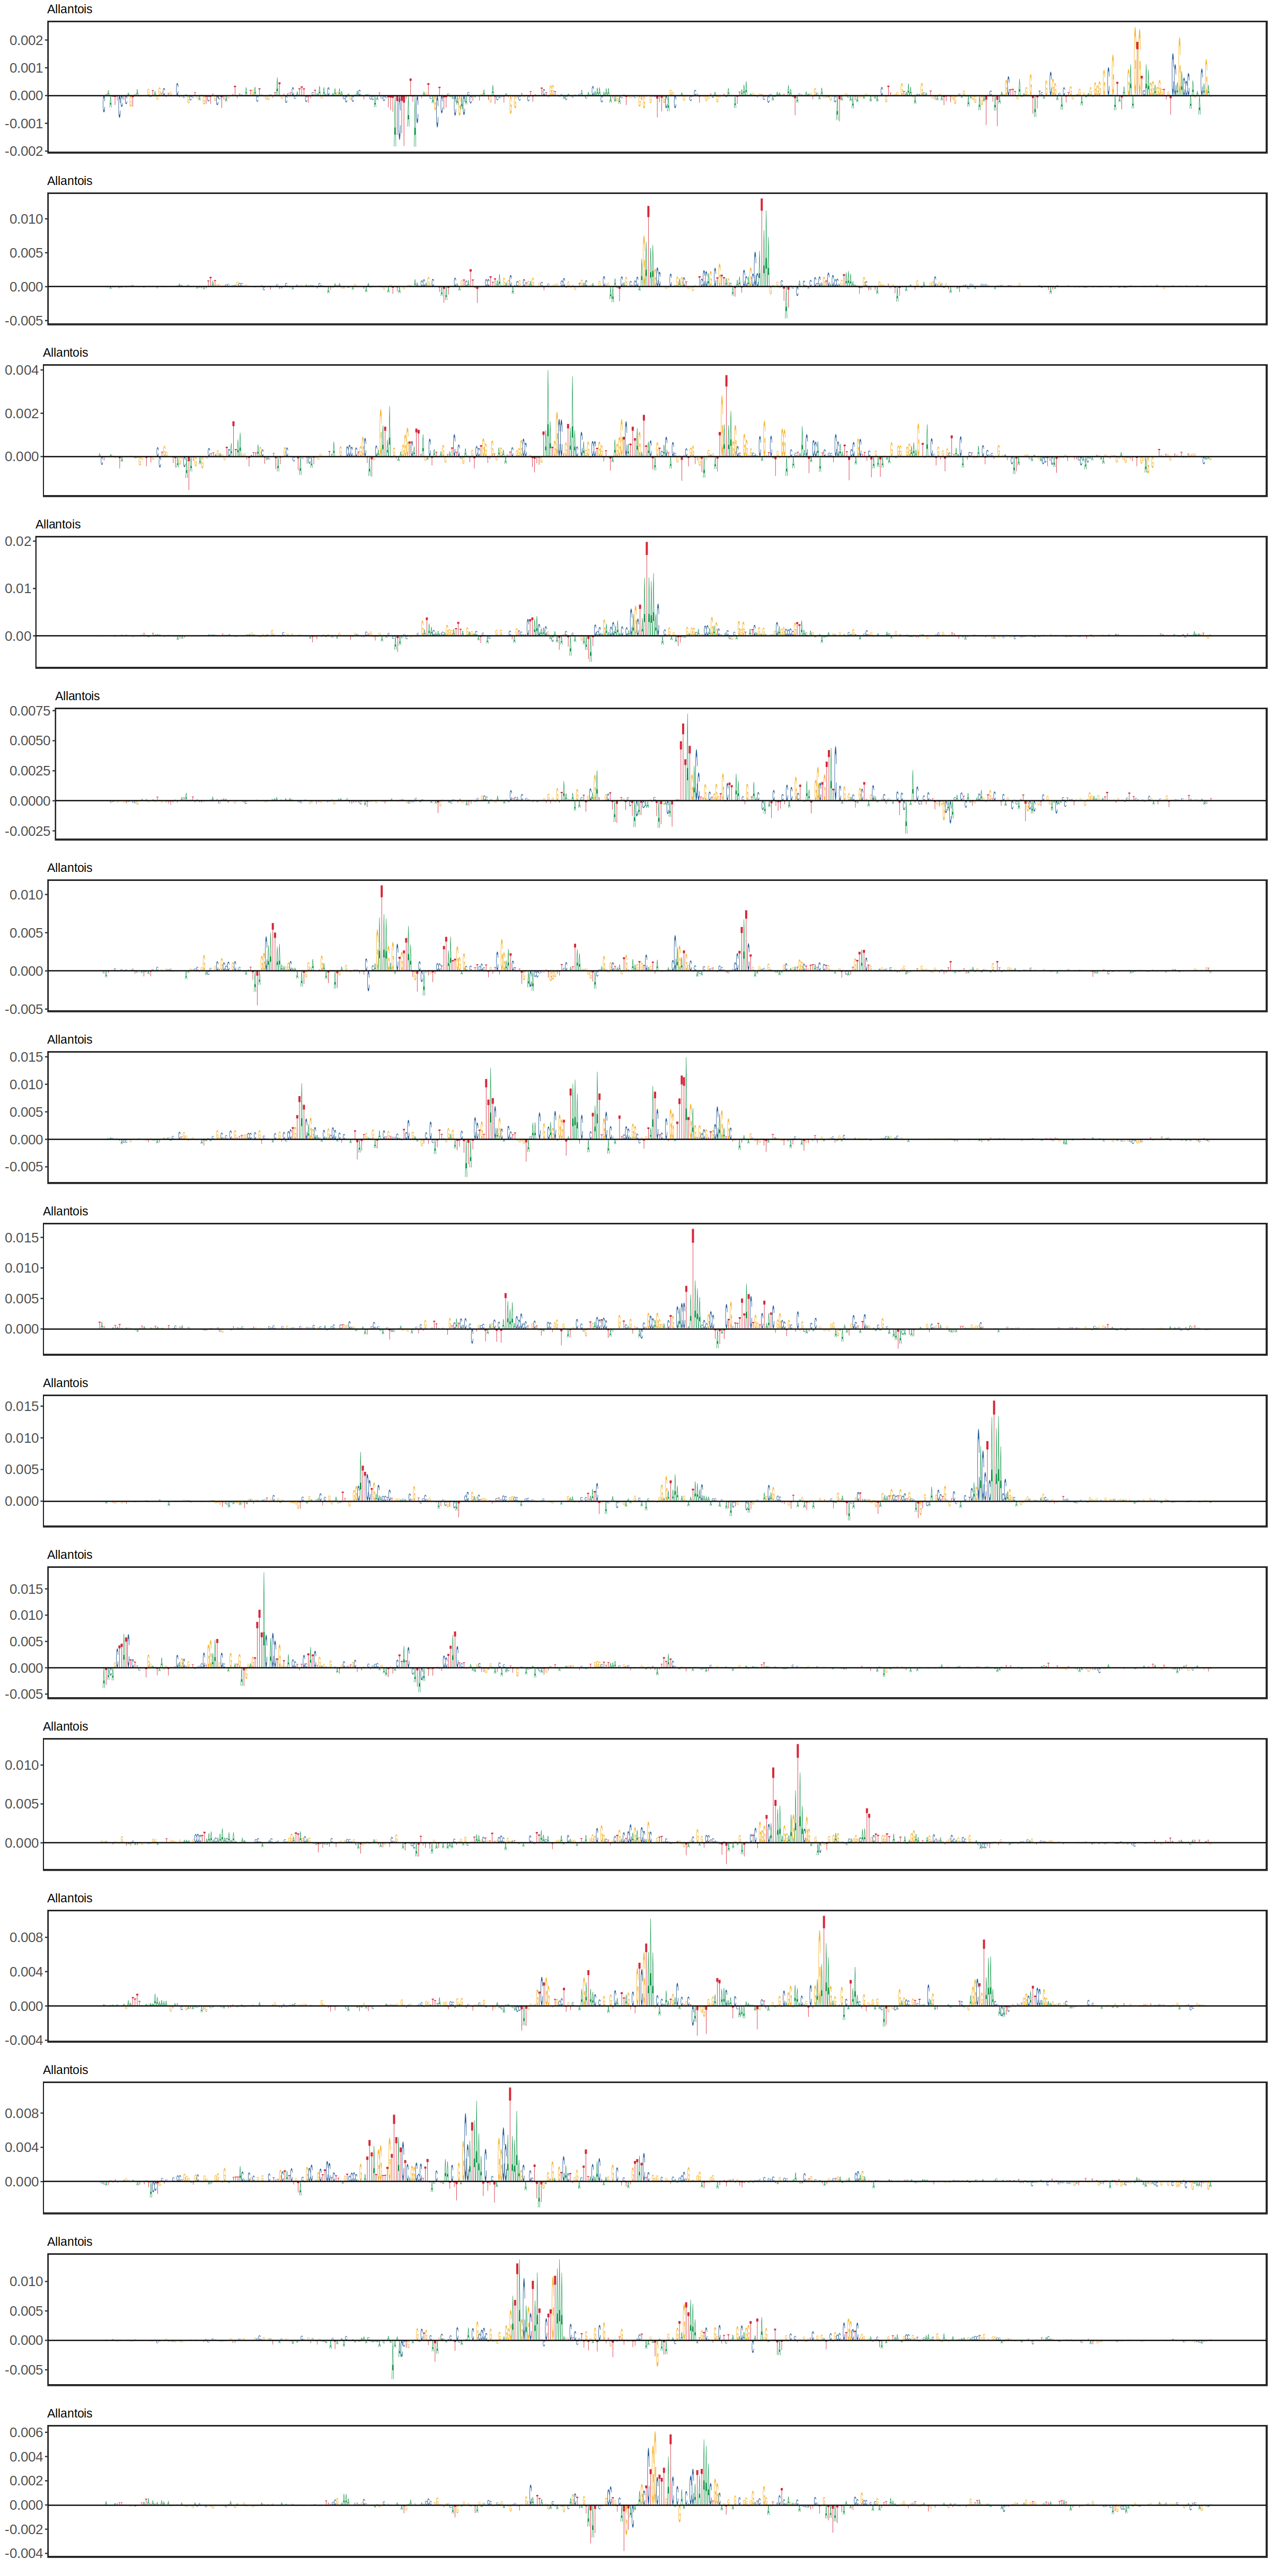

In [209]:
options(repr.plot.width = 20, repr.plot.height = 2.7*15)

ggarrange(plotlist = lapply(1:15, function(x){
    plot_peak(row = peaks %>% .[V4 == 'Allantois'] %>% .$I %>% .[x], width = 500, celltypes = 'Allantois')
}), align = 'hv', ncol = 1)

In [210]:
profiles = mclapply(celltypes, function(celltype){
    tmp = h5read(
        sprintf('/rds/project/rds-SDzz0CATGms/users/bt392/atlasses/gastrulation_multiome/results/atac/chrombpnet/predictions/%s_prediction.counts_scores.h5', celltype), 
        "/projected_shap/seq")
    return(tmp)
},mc.cores = 8)

names(profiles) = celltypes

In [211]:
row = peaks %>% .[V4 == 'Endothelium'] %>% .$I %>% .[1]
width = 350
plot_peak = function(row, width = 350, celltypes_plot = celltypes, centre_on_max = FALSE){
    profiles_peak = lapply(profiles, function(x){
        tmp = x[(2114 * (row-1)*4 + 1): (2114 * ((row-1) * 4) + 2114*4)]
        genome_endo = data.table(A = tmp[1:2114],
                   C = tmp[2115:4228],
                   G =  tmp[4229:6342],
                   T =  tmp[6343:8456]
                   ) %>% 
                    .[, position := .I] 

        if(centre_on_max){ # Centering does not work yet
            centre = which(profiles_peak[[celltypes_plot]] == max(profiles_peak[[celltypes_plot]]))/4+1
            genome_endo = genome_endo %>% 
                    .[position > centre - width/2 & position < centre + width/2] %>% 
                    .[, position := NULL]
        }else{
            genome_endo = genome_endo %>% 
                .[position > 1057 - width/2 & position < 1057 + width/2] %>% 
                .[, position := NULL]
        }
        
        genome_endo = as.matrix(t(genome_endo))
    })

    profiles_peak_tmp = profiles_peak[celltypes_plot]
    plots = lapply(1:length(profiles_peak_tmp), function(x){
          p1 = ggseqlogo(profiles_peak_tmp[[x]], method='custom', seq_type='dna') + ylab('my custom height') + 
            geom_hline(yintercept = 0) +
            ylim(min(sapply(profiles_peak_tmp, min)), max(sapply(profiles_peak_tmp, max))) + 
            ggtitle(names(profiles_peak_tmp)[[x]]) + 
                theme_bw() + 
                theme(panel.grid = element_blank(), 
                      panel.background = element_rect(color = 'black', fill = NA, linewidth = 1),
                      axis.text.y = element_text(size = 15),
                     axis.title.y = element_blank(),
                     axis.text.x = element_blank(),
                     axis.ticks.x = element_blank())
    })

    ggarrange(plotlist = plots, ncol = 1, align = 'hv')
}

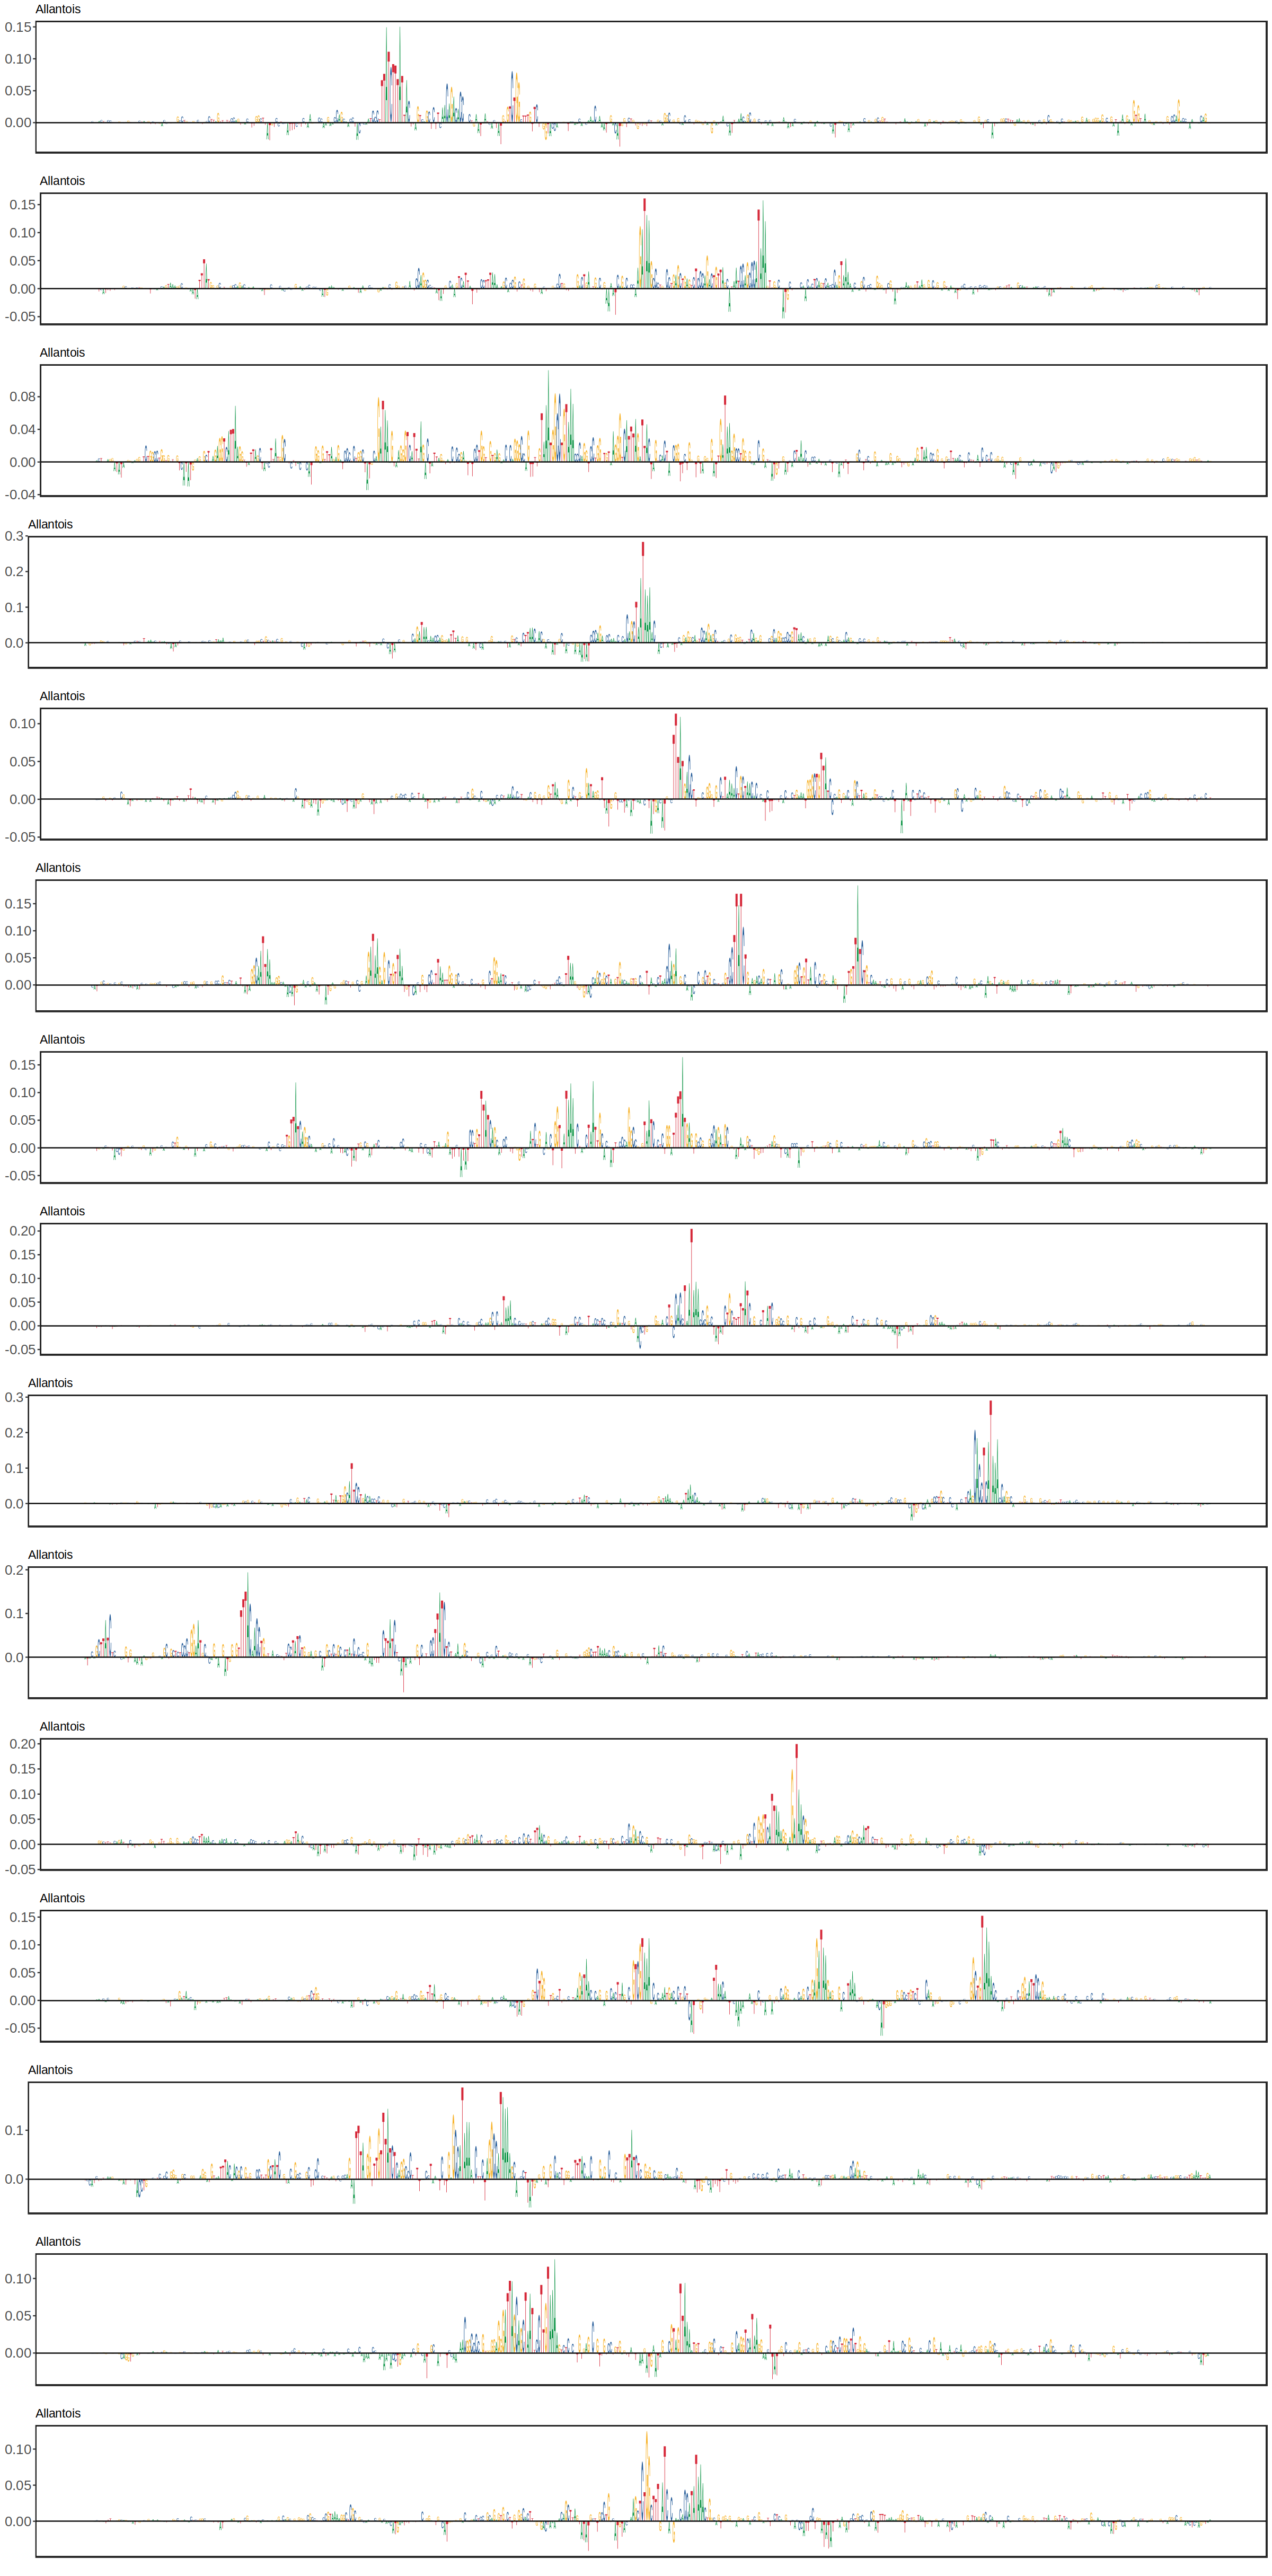

In [212]:
ggarrange(plotlist = lapply(1:15, function(x){
    plot_peak(row = peaks %>% .[V4 == 'Allantois'] %>% .$I %>% .[x], width = 500, celltypes = 'Allantois')
}), align = 'hv', ncol = 1)

In [219]:
celltypes

[1] "Gut"                          "Mesenchyme"                  
 [3] "Primitive_Streak"             "Nascent_mesoderm"            
 [5] "Forebrain_Midbrain_Hindbrain" "Somitic_mesoderm"            
 [7] "Spinal_cord"                  "Endothelium"                 
 [9] "Allantois"                    "Cardiomyocytes"              
[11] "Erythroid1"

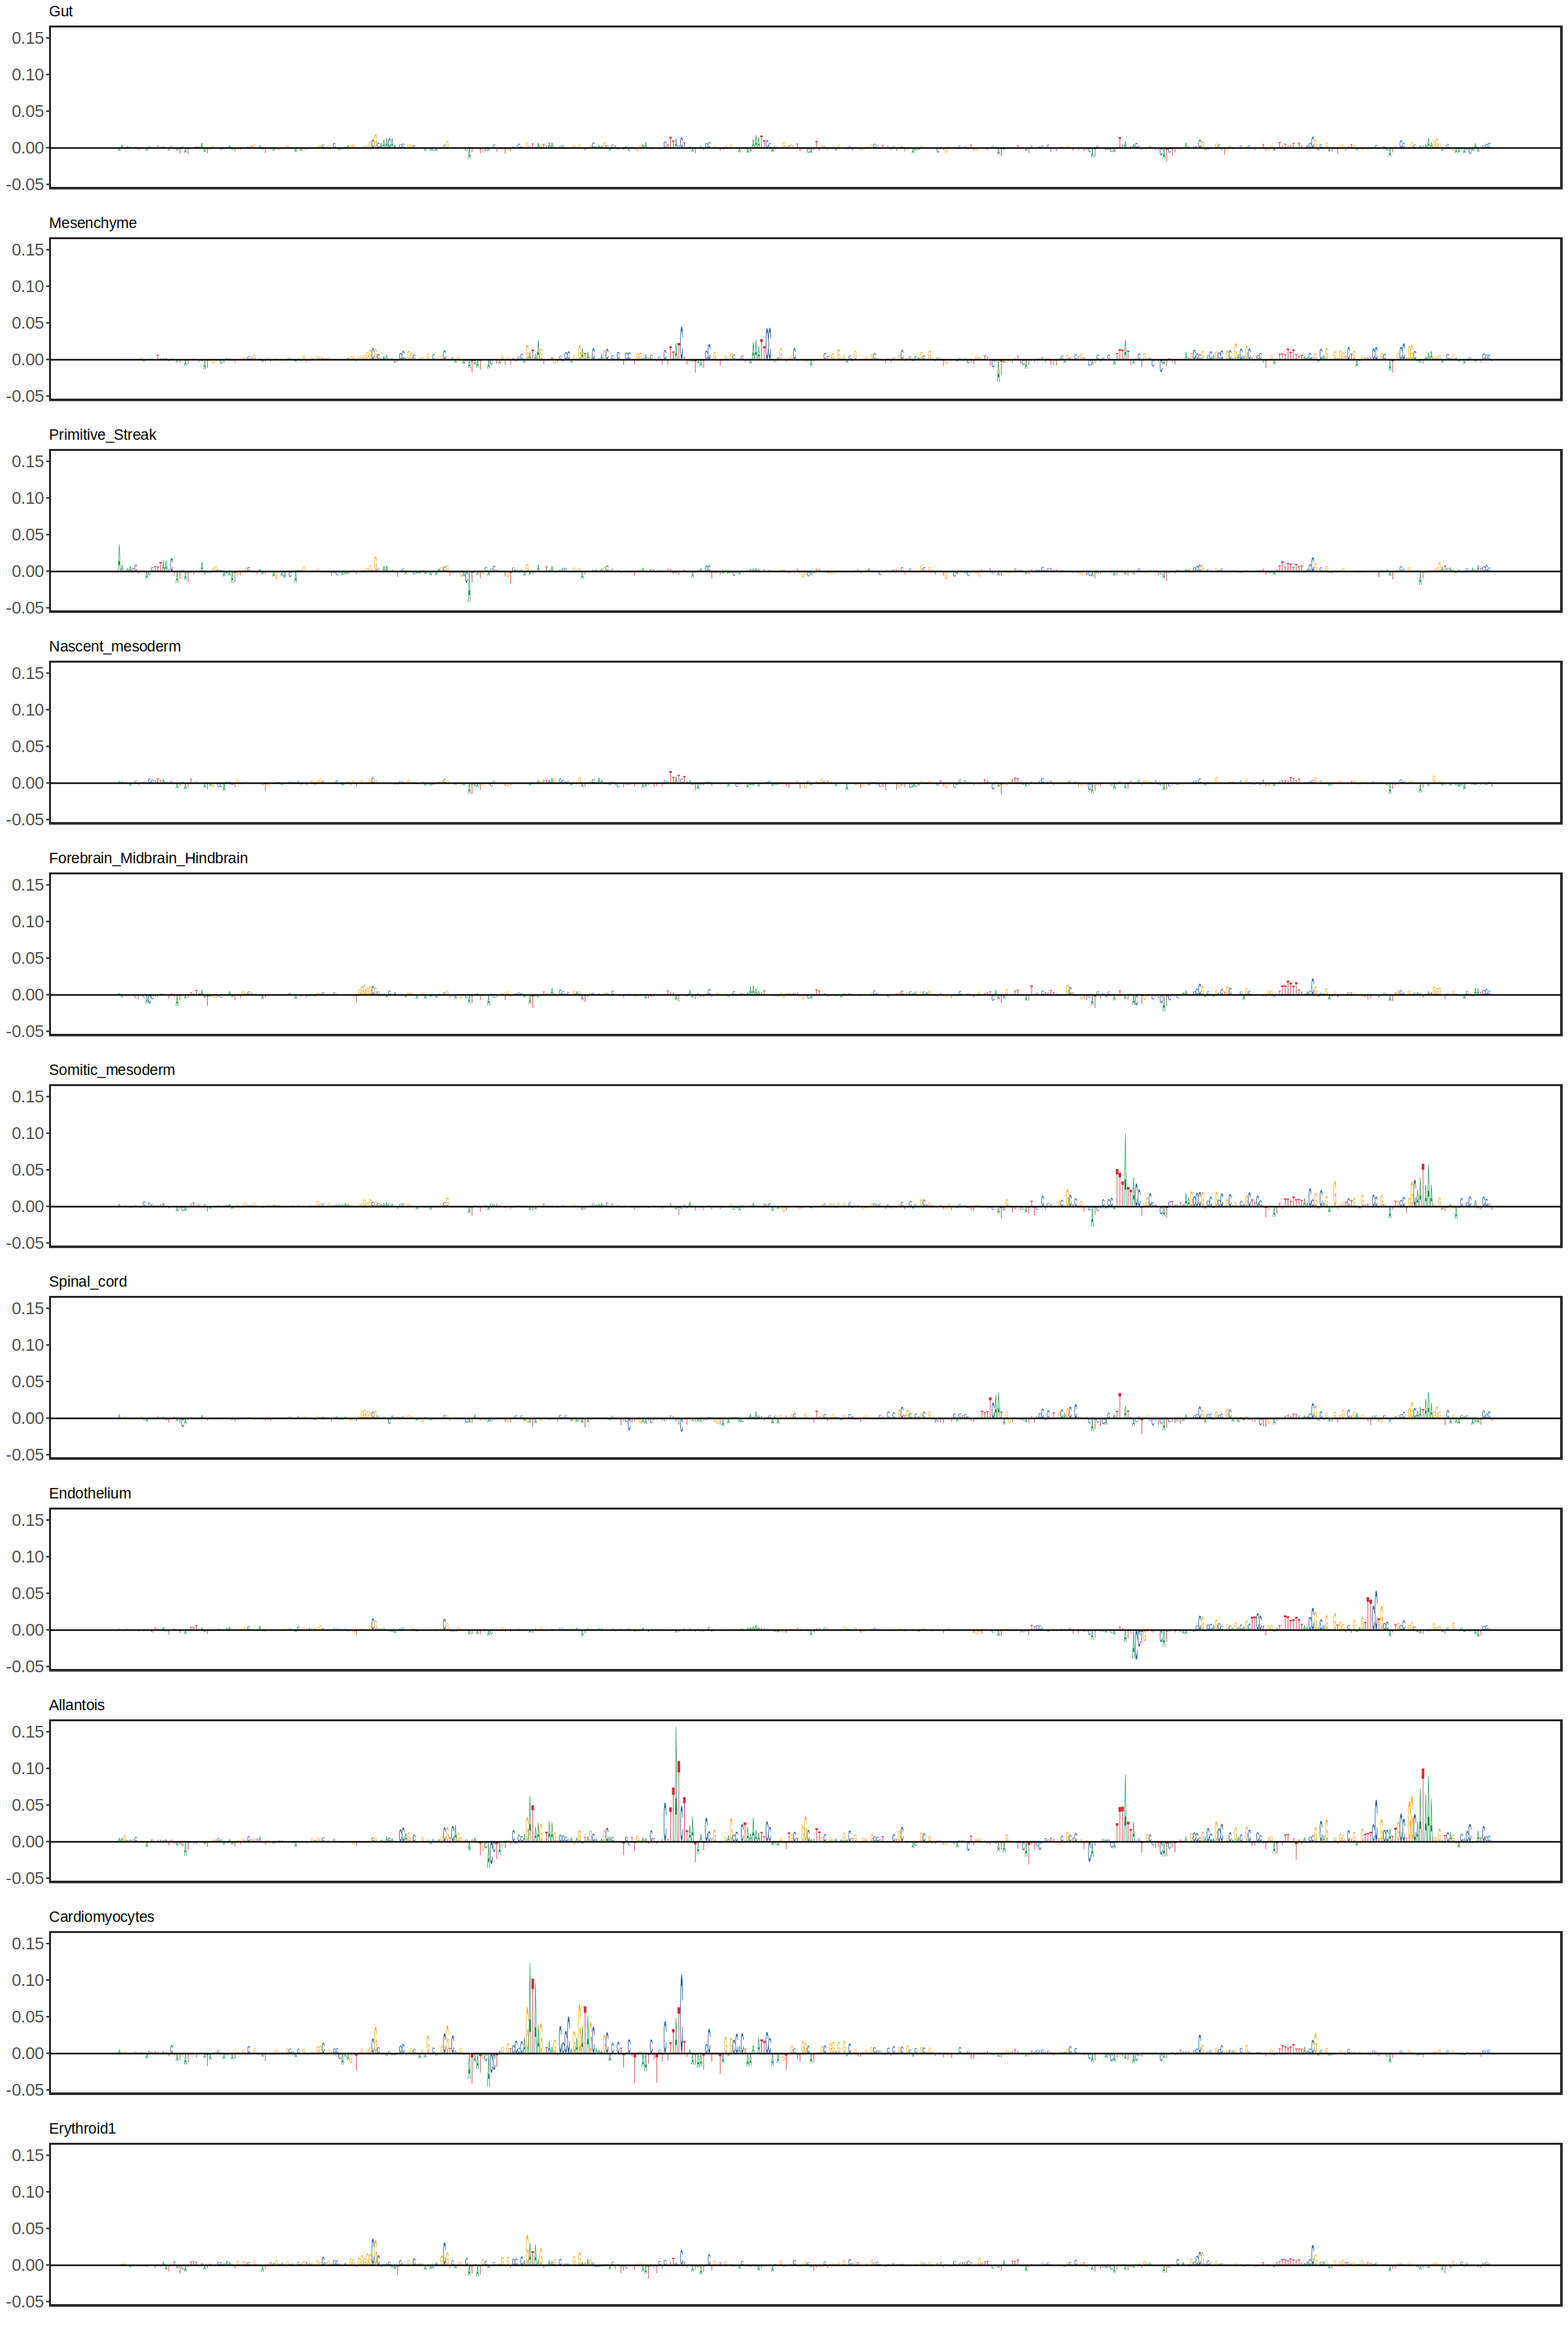

In [240]:
options(repr.plot.width = 20, repr.plot.height = 2.7*11)

plot_peak(row = peaks %>% .[V4 == 'Allantois'] %>% .$I %>% .[40], width = 500)